<a href="https://colab.research.google.com/github/darshanp99/FUTURE_ML_01/blob/main/Future_Ml_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle


In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darshanp99","key":"0e691d1256355e739e47eae354ce0305"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle competitions download -c store-sales-time-series-forecasting

  0% 0.00/21.4M [00:00<?, ?B/s]
100% 21.4M/21.4M [00:00<00:00, 786MB/s]


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import zipfile

zip_path = "store-sales-time-series-forecasting.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("sales_dataset")

In [22]:
import pandas as pd

df = pd.read_csv("sales_dataset/train.csv")
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [23]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [24]:
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [25]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

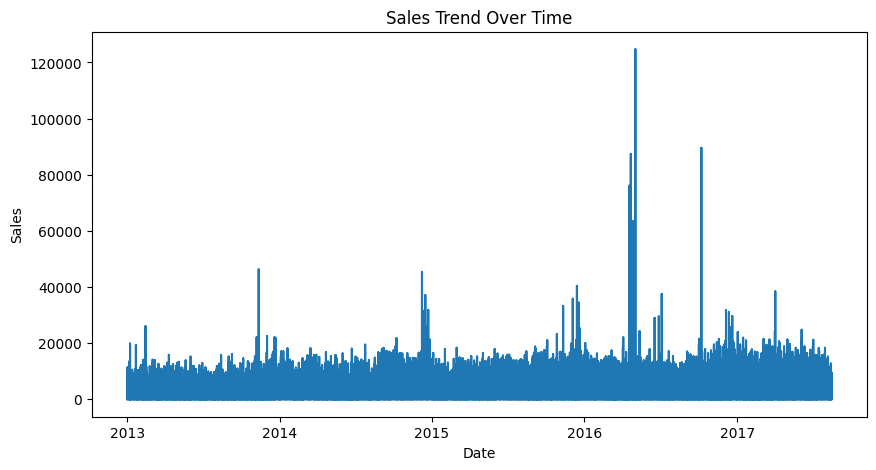

In [26]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X = df[['year','month','day','day_of_week']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 509.8163183612186


In [30]:
future_dates = pd.date_range(start=df['date'].max(), periods=30)

future_df = pd.DataFrame({
    'year': future_dates.year,
    'month': future_dates.month,
    'day': future_dates.day,
    'day_of_week': future_dates.dayofweek
})

future_sales = model.predict(future_df)

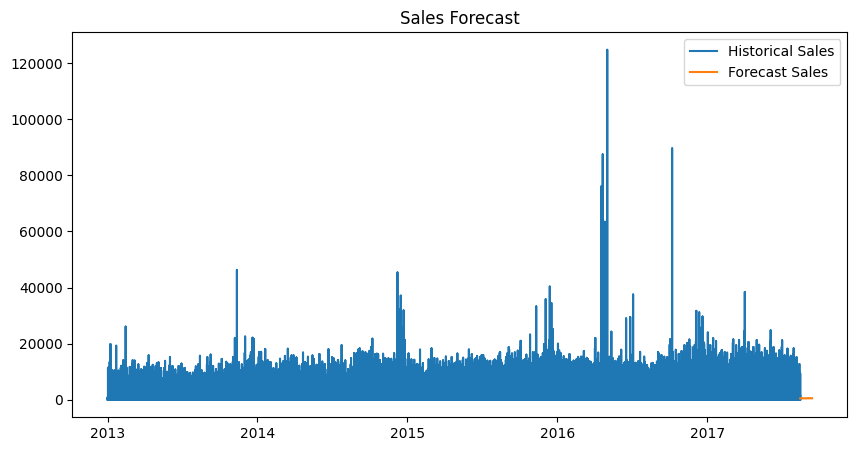

In [31]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'], label="Historical Sales")
plt.plot(future_dates, future_sales, label="Forecast Sales")
plt.legend()
plt.title("Sales Forecast")
plt.show()